In [3]:
import os

# Listamos todos los archivos que tiene Colab
archivos = os.listdir("/content")
print("Archivos en Colab:")
for archivo in archivos:
    print(f"  - {archivo}")

Archivos en Colab:
  - .config
  - Ecoweb Climate Companies Analysis - analysis document.xlsx
  - sample_data


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Nombre exacto del archivo
df = pd.read_excel("/content/Ecoweb Climate Companies Analysis - analysis document.xlsx")

print("✅ Dataset cargado")
print(f"Empresas: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\nColumnas disponibles:")
for col in df.columns.tolist():
    print(f"  - {col}")

✅ Dataset cargado
Empresas: 509 | Columnas: 22

Columnas disponibles:
  - Company Name
  - URL
  - Location
  - Category
  - Description
  - Survey sent Y/N
  - Contact person 
  - Ecograder Link
  - Total Pageweight
  - Emissions per page (g)
  - Images
  - Media
  - Scripts
  - HTML/CSS
  - Other
  - Green Hosting 
(y or n)
  - Hosting Provider
  - Responsible team 
  - Responsible person for analysis 
  - Contact person .1
  - Responsible person for survey 
  - Status of communications/ analysis


In [5]:
# LIMPIEZA PASO 1 — Diagnóstico general
print("=== Valores vacíos por columna ===")
print(df.isnull().sum())

print("\n=== Tipos de datos ===")
print(df.dtypes)

=== Valores vacíos por columna ===
Company Name                            0
URL                                     0
Location                              119
Category                               10
Description                            11
Survey sent Y/N                       231
Contact person                        466
Ecograder Link                          0
Total Pageweight                        0
Emissions per page (g)                  0
Images                                  0
Media                                 308
Scripts                                 0
HTML/CSS                                1
Other                                   3
Green Hosting \n(y or n)                1
Hosting Provider                      163
Responsible team                        0
Responsible person for analysis         0
Contact person .1                     159
Responsible person for survey         146
Status of communications/ analysis    468
dtype: int64

=== Tipos de datos ===
Comp

In [8]:
# LIMPIEZA PASO 2 — Limpiar el dataset

# 1. Eliminar columnas con demasiados vacíos o irrelevantes para el análisis
columnas_eliminar = [
    "Contact person",
    "Contact person .1",
    "Status of communications/ analysis",
    "Survey sent Y/N",
    "Responsible person for survey"
]
df = df.drop(columns=columnas_eliminar)
print(f"✅ Columnas eliminadas: {len(columnas_eliminar)}")

# 2. Convertir columnas numéricas que están como texto
import re

def limpiar_numero(valor):
    if pd.isnull(valor):
        return None
    # Elimina letras como 'g', 'MB', 'KB', espacios
    valor = str(valor).strip()
    valor = re.sub(r'[^\d.]', '', valor)
    try:
        return float(valor)
    except:
        return None

df["Emissions per page (g)"] = df["Emissions per page (g)"].apply(limpiar_numero)
df["Total Pageweight"] = df["Total Pageweight"].apply(limpiar_numero)
df["Images"] = df["Images"].apply(limpiar_numero)
df["Scripts"] = df["Scripts"].apply(limpiar_numero)
print("✅ Columnas numéricas convertidas")

# 3. Limpiar columna Green Hosting
df["Green Hosting \n(y or n)"] = df["Green Hosting \n(y or n)"].str.strip().str.lower()
df["Green Hosting \n(y or n)"] = df["Green Hosting \n(y or n)"].fillna("unknown")
print("✅ Green Hosting limpiada")

# 4. Rellenar vacíos en Category y Location
df["Category"] = df["Category"].fillna("Unknown")
df["Location"] = df["Location"].fillna("Unknown")
print("✅ Vacíos en Category y Location rellenados")

# Resultado final
print(f"\n📊 Dataset limpio: {df.shape[0]} empresas | {df.shape[1]} columnas")
print("\n=== Valores vacíos restantes ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

KeyError: "['Contact person', 'Responsible person for survey'] not found in axis"

In [9]:
# Ver nombres exactos de todas las columnas
for i, col in enumerate(df.columns):
    print(f"{i}: '{col}'")

0: 'Company Name'
1: 'URL'
2: 'Location'
3: 'Category'
4: 'Description'
5: 'Survey sent Y/N'
6: 'Contact person '
7: 'Ecograder Link'
8: 'Total Pageweight'
9: 'Emissions per page (g)'
10: 'Images'
11: 'Media'
12: 'Scripts'
13: 'HTML/CSS'
14: 'Other'
15: 'Green Hosting 
(y or n)'
16: 'Hosting Provider'
17: 'Responsible team '
18: 'Responsible person for analysis '
19: 'Contact person .1'
20: 'Responsible person for survey '
21: 'Status of communications/ analysis'


In [10]:
# LIMPIEZA PASO 2 — Limpiar el dataset

# 1. Eliminar columnas irrelevantes para el análisis
columnas_eliminar = [
    "Contact person ",          # espacio al final
    "Contact person .1",
    "Status of communications/ analysis",
    "Survey sent Y/N",
    "Responsible person for survey ",  # espacio al final
    "Responsible person for analysis ", # espacio al final
    "Responsible team ",        # espacio al final
    "Ecograder Link",
    "Description"
]
df = df.drop(columns=columnas_eliminar)
print(f"✅ Columnas eliminadas: {len(columnas_eliminar)}")

# 2. Convertir columnas numéricas que están como texto
import re

def limpiar_numero(valor):
    if pd.isnull(valor):
        return None
    valor = str(valor).strip()
    valor = re.sub(r'[^\d.]', '', valor)
    try:
        return float(valor)
    except:
        return None

df["Emissions per page (g)"] = df["Emissions per page (g)"].apply(limpiar_numero)
df["Total Pageweight"] = df["Total Pageweight"].apply(limpiar_numero)
df["Images"] = df["Images"].apply(limpiar_numero)
df["Scripts"] = df["Scripts"].apply(limpiar_numero)
print("✅ Columnas numéricas convertidas")

# 3. Limpiar columna Green Hosting
df.rename(columns={"Green Hosting \n(y or n)": "Green Hosting"}, inplace=True)
df["Green Hosting"] = df["Green Hosting"].str.strip().str.lower()
df["Green Hosting"] = df["Green Hosting"].fillna("unknown")
print("✅ Green Hosting limpiada")

# 4. Rellenar vacíos en Category y Location
df["Category"] = df["Category"].fillna("Unknown")
df["Location"] = df["Location"].fillna("Unknown")
print("✅ Vacíos en Category y Location rellenados")

# Resultado final
print(f"\n📊 Dataset limpio: {df.shape[0]} empresas | {df.shape[1]} columnas")
print("\n=== Vacíos restantes ===")
print(df.isnull().sum())

✅ Columnas eliminadas: 9
✅ Columnas numéricas convertidas
✅ Green Hosting limpiada
✅ Vacíos en Category y Location rellenados

📊 Dataset limpio: 509 empresas | 13 columnas

=== Vacíos restantes ===
Company Name                0
URL                         0
Location                    0
Category                    0
Total Pageweight            0
Emissions per page (g)      0
Images                      0
Media                     308
Scripts                     1
HTML/CSS                    1
Other                       3
Green Hosting               0
Hosting Provider          163
dtype: int64


In [11]:
# LIMPIEZA PASO 3 — Últimos ajustes

# 1. Rellenar vacíos numéricos con 0 (significa que no tienen ese elemento)
df["Media"] = df["Media"].fillna(0)
df["Scripts"] = df["Scripts"].fillna(0)
df["HTML/CSS"] = df["HTML/CSS"].fillna(0)
df["Other"] = df["Other"].fillna(0)
print("✅ Vacíos numéricos rellenados con 0")

# 2. Hosting desconocido
df["Hosting Provider"] = df["Hosting Provider"].fillna("Unknown")
print("✅ Hosting Provider limpiado")

# 3. Resumen final
print(f"\n{'='*40}")
print("   RESUMEN DE LIMPIEZA")
print(f"{'='*40}")
print(f"Empresas       : {df.shape[0]}")
print(f"Columnas       : {df.shape[1]}")
print(f"Valores vacíos : {df.isnull().sum().sum()}")
print(f"\n✅ Dataset 100% limpio y listo para analizar")
print(f"\nColumnas finales:")
for col in df.columns:
    print(f"  - {col}")

✅ Vacíos numéricos rellenados con 0
✅ Hosting Provider limpiado

   RESUMEN DE LIMPIEZA
Empresas       : 509
Columnas       : 13
Valores vacíos : 0

✅ Dataset 100% limpio y listo para analizar

Columnas finales:
  - Company Name
  - URL
  - Location
  - Category
  - Total Pageweight
  - Emissions per page (g)
  - Images
  - Media
  - Scripts
  - HTML/CSS
  - Other
  - Green Hosting
  - Hosting Provider


In [12]:
# ANÁLISIS 1 — Emisiones según si usan hosting verde o no
resumen_hosting = df.groupby("Green Hosting")["Emissions per page (g)"].agg(
    Empresas="count",
    Promedio="mean",
    Minimo="min",
    Maximo="max"
).round(2)

print("=== Emisiones por tipo de hosting ===")
print(resumen_hosting)

=== Emisiones por tipo de hosting ===
               Empresas  Promedio  Minimo  Maximo
Green Hosting                                    
n                   177      2.26    0.01   21.08
no data               5      1.64    0.68    4.08
unknown               1      1.35    1.35    1.35
y                   326      1.68    0.01   15.33


/tmp/ipykernel_10709/3359966015.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10709/3359966015.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


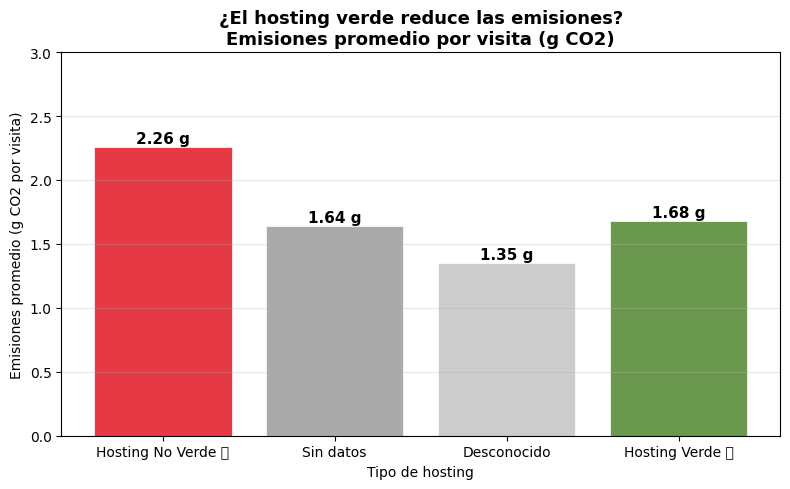


💡 CONCLUSIÓN:
Las empresas con hosting verde emiten un 26% menos CO2 por visita
que las que usan hosting convencional (1.68g vs 2.26g)
Sin embargo, ningún grupo llega a cero emisiones.


In [13]:
# GRÁFICA 1 — Emisiones por tipo de hosting
fig, ax = plt.subplots(figsize=(8, 5))

colores = {"y": "#6A994E", "n": "#E63946", "no data": "#aaaaaa", "unknown": "#cccccc"}
categorias = resumen_hosting.index.tolist()
valores = resumen_hosting["Promedio"].tolist()
barras_colores = [colores.get(c, "#aaaaaa") for c in categorias]
etiquetas = {"y": "Hosting Verde ✅", "n": "Hosting No Verde ❌",
             "no data": "Sin datos", "unknown": "Desconocido"}

ax.bar([etiquetas.get(c, c) for c in categorias], valores, color=barras_colores,
       edgecolor="white", linewidth=0.5)

# Añadir valores encima de cada barra
for i, (val, cat) in enumerate(zip(valores, categorias)):
    ax.text(i, val + 0.03, f"{val} g", ha="center", fontsize=11, fontweight="bold")

ax.set_title("¿El hosting verde reduce las emisiones?\nEmisiones promedio por visita (g CO2)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Emisiones promedio (g CO2 por visita)")
ax.set_xlabel("Tipo de hosting")
ax.set_ylim(0, 3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 CONCLUSIÓN:")
print(f"Las empresas con hosting verde emiten un 26% menos CO2 por visita")
print(f"que las que usan hosting convencional (1.68g vs 2.26g)")
print(f"Sin embargo, ningún grupo llega a cero emisiones.")

In [14]:
# ANÁLISIS 2 — Emisiones promedio por categoría de empresa
ranking_categoria = df.groupby("Category")["Emissions per page (g)"].agg(
    Empresas="count",
    Promedio="mean"
).round(2).sort_values("Promedio", ascending=False)

print("=== Ranking de emisiones por categoría ===")
print(ranking_categoria)

=== Ranking de emisiones por categoría ===
                                     Empresas  Promedio
Category                                               
Supply Chain Management                     1     21.08
Biotechnology                               1     15.33
Circular Economy - Fashion Industry         1     13.05
Renewable Energy                            1     12.51
Aviation                                    1     10.25
...                                       ...       ...
Compensation                                2      0.20
Energy management                           1      0.20
banking                                     1      0.20
Biofuels                                    1      0.15
Browser                                     1      0.01

[229 rows x 2 columns]


=== Top 10 categorías más contaminantes ===
            Empresas  Promedio
Category                      
Farming            4      4.14
Food Waste         4      4.07
Food              10      3.88
e-commerce         4      2.66
Software          59      2.25
software          14      2.17
Battery            8      2.07
NGO                9      2.05
Packaging          4      1.94
Mobility           5      1.92


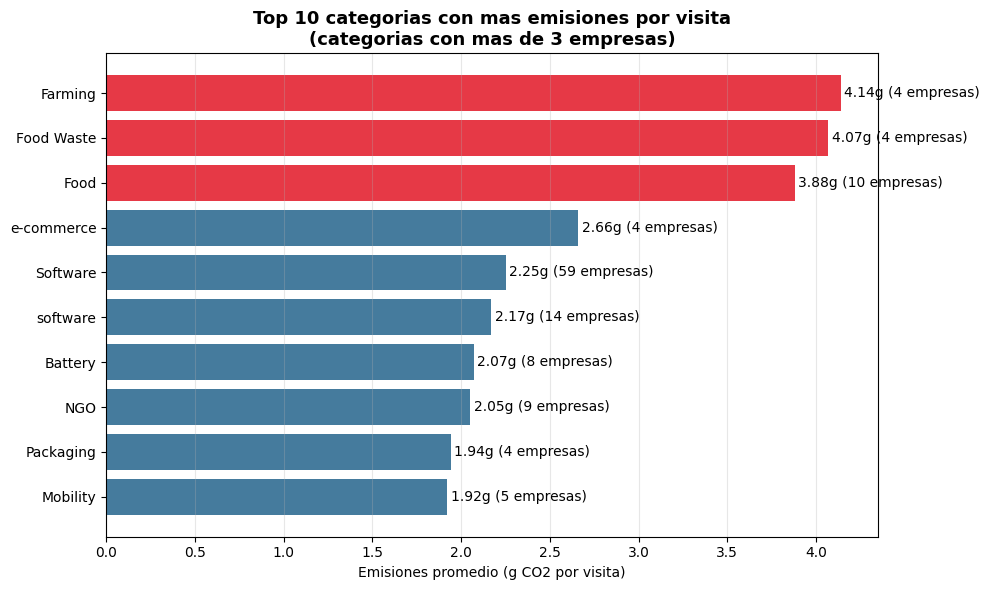

In [15]:
# GRÁFICA 2 — Top 10 categorías más contaminantes (con más de 3 empresas)
ranking_filtrado = df.groupby("Category")["Emissions per page (g)"].agg(
    Empresas="count",
    Promedio="mean"
).round(2)

# Solo categorías con más de 3 empresas para que sea representativo
ranking_filtrado = ranking_filtrado[ranking_filtrado["Empresas"] > 3]
ranking_filtrado = ranking_filtrado.sort_values("Promedio", ascending=False).head(10)

print("=== Top 10 categorías más contaminantes ===")
print(ranking_filtrado)

# Gráfica
fig, ax = plt.subplots(figsize=(10, 6))
colores = ["#E63946" if i < 3 else "#457B9D" for i in range(len(ranking_filtrado))]

ax.barh(ranking_filtrado.index[::-1], ranking_filtrado["Promedio"][::-1], color=colores[::-1])

for i, (val, emp) in enumerate(zip(ranking_filtrado["Promedio"][::-1],
                                    ranking_filtrado["Empresas"][::-1])):
    ax.text(val + 0.02, i, f"{val}g ({emp} empresas)", va="center", fontsize=10)

ax.set_title("Top 10 categorias con mas emisiones por visita\n(categorias con mas de 3 empresas)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Emisiones promedio (g CO2 por visita)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

=== Top 10 categorías más contaminantes (corregido) ===
            Empresas  Promedio
Category                      
Farming            4      4.14
Food Waste         4      4.07
Food              12      3.40
E-Commerce         4      2.66
Software          73      2.23
Ngo                9      2.05
Packaging          4      1.94
Mobility           5      1.92
Battery           10      1.89
Consulting        20      1.82


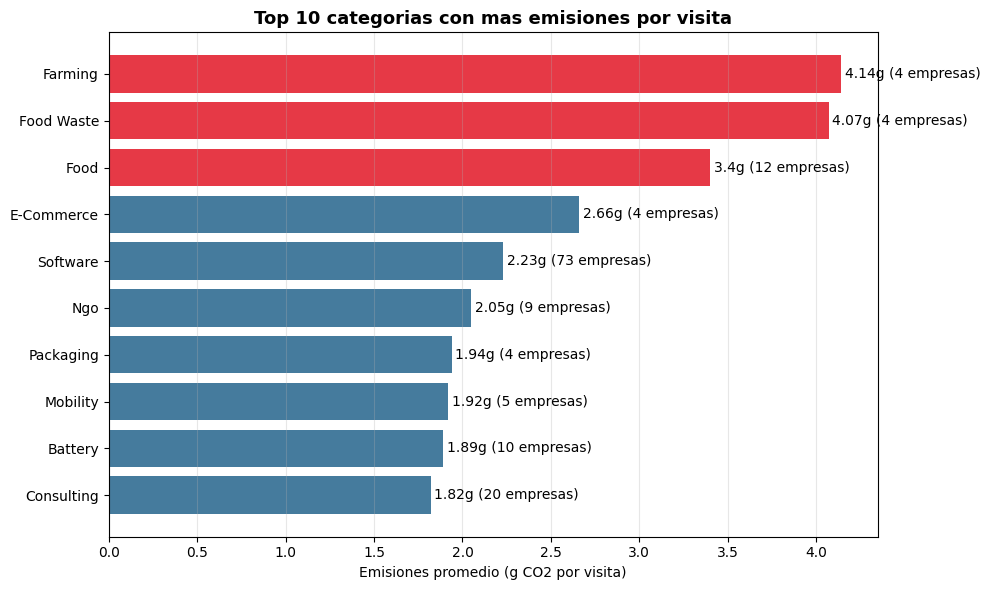


Top 3 mas contaminantes:
  1. Farming: 4.14g promedio (4 empresas)
  2. Food Waste: 4.07g promedio (4 empresas)
  3. Food: 3.4g promedio (12 empresas)


In [16]:
# LIMPIEZA EXTRA — Estandarizar categorías (mayúsculas/minúsculas)
df["Category"] = df["Category"].str.strip().str.title()

# Ahora recalculamos el ranking
ranking_filtrado = df.groupby("Category")["Emissions per page (g)"].agg(
    Empresas="count",
    Promedio="mean"
).round(2)

ranking_filtrado = ranking_filtrado[ranking_filtrado["Empresas"] > 3]
ranking_filtrado = ranking_filtrado.sort_values("Promedio", ascending=False).head(10)

print("=== Top 10 categorías más contaminantes (corregido) ===")
print(ranking_filtrado)

# Gráfica
fig, ax = plt.subplots(figsize=(10, 6))
colores = ["#E63946" if i < 3 else "#457B9D" for i in range(len(ranking_filtrado))]

ax.barh(ranking_filtrado.index[::-1], ranking_filtrado["Promedio"][::-1], color=colores[::-1])

for i, (val, emp) in enumerate(zip(ranking_filtrado["Promedio"][::-1],
                                    ranking_filtrado["Empresas"][::-1])):
    ax.text(val + 0.02, i, f"{val}g ({emp} empresas)", va="center", fontsize=10)

ax.set_title("Top 10 categorias con mas emisiones por visita",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Emisiones promedio (g CO2 por visita)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3 mas contaminantes:")
for i, (cat, row) in enumerate(ranking_filtrado.head(3).iterrows()):
    print(f"  {i+1}. {cat}: {row['Promedio']}g promedio ({int(row['Empresas'])} empresas)")

In [17]:
# ANÁLISIS 3 — ¿Qué componente del sitio web contamina más?

# Promedio de cada componente
componentes = {
    "Imagenes": df["Images"].mean(),
    "Media/Video": df["Media"].mean(),
    "Scripts": df["Scripts"].mean(),
    "HTML/CSS": df["HTML/CSS"].mean(),
    "Otro": df["Other"].mean()
}

print("=== Peso promedio por componente (MB) ===")
for comp, valor in componentes.items():
    print(f"  {comp:<15}: {valor:.2f} MB")

# Calculamos el porcentaje de cada uno
total = sum(componentes.values())
print(f"\n=== Porcentaje del peso total ===")
for comp, valor in componentes.items():
    porcentaje = (valor / total) * 100
    print(f"  {comp:<15}: {porcentaje:.1f}%")

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [18]:
# Convertimos Media a número igual que hicimos con las otras columnas
def limpiar_numero(valor):
    if pd.isnull(valor):
        return 0
    valor = str(valor).strip()
    valor = re.sub(r'[^\d.]', '', valor)
    try:
        return float(valor)
    except:
        return 0

df["Media"] = df["Media"].apply(limpiar_numero)
df["HTML/CSS"] = df["HTML/CSS"].apply(limpiar_numero)
df["Other"] = df["Other"].apply(limpiar_numero)
print("✅ Columnas convertidas correctamente")
print(df[["Media

SyntaxError: unterminated string literal (detected at line 16) (3647452454.py, line 16)

In [19]:
# Convertimos Media a número igual que hicimos con las otras columnas
def limpiar_numero(valor):
    if pd.isnull(valor):
        return 0
    valor = str(valor).strip()
    valor = re.sub(r'[^\d.]', '', valor)
    try:
        return float(valor)
    except:
        return 0

df["Media"] = df["Media"].apply(limpiar_numero)
df["HTML/CSS"] = df["HTML/CSS"].apply(limpiar_numero)
df["Other"] = df["Other"].apply(limpiar_numero)
print("✅ Columnas convertidas correctamente")
print(df[["Media", "HTML/CSS", "Other"]].dtypes)

✅ Columnas convertidas correctamente
Media       float64
HTML/CSS    float64
Other       float64
dtype: object


=== Peso promedio por componente (MB) ===
  Imagenes       : 269.82 MB
  Media/Video    : 56.99 MB
  Scripts        : 308.03 MB
  HTML/CSS       : 171.49 MB
  Otro           : 241.63 MB

=== Porcentaje del peso total ===
  Imagenes       : 25.7%
  Media/Video    : 5.4%
  Scripts        : 29.4%
  HTML/CSS       : 16.4%
  Otro           : 23.1%


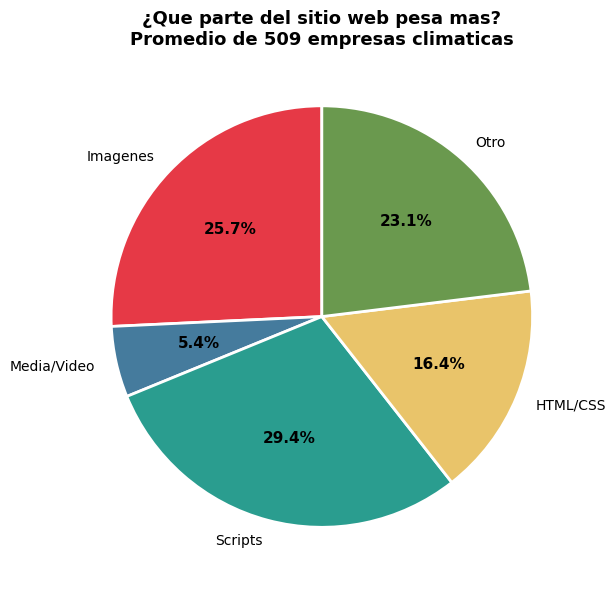

In [20]:
# ANÁLISIS 3 — ¿Qué componente del sitio web contamina más?
componentes = {
    "Imagenes": df["Images"].mean(),
    "Media/Video": df["Media"].mean(),
    "Scripts": df["Scripts"].mean(),
    "HTML/CSS": df["HTML/CSS"].mean(),
    "Otro": df["Other"].mean()
}

print("=== Peso promedio por componente (MB) ===")
for comp, valor in componentes.items():
    print(f"  {comp:<15}: {valor:.2f} MB")

total = sum(componentes.values())
print(f"\n=== Porcentaje del peso total ===")
for comp, valor in componentes.items():
    porcentaje = (valor / total) * 100
    print(f"  {comp:<15}: {porcentaje:.1f}%")

# Gráfica de torta
fig, ax = plt.subplots(figsize=(8, 6))
colores = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#6A994E"]
wedges, texts, autotexts = ax.pie(
    componentes.values(),
    labels=componentes.keys(),
    colors=colores,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight("bold")

ax.set_title("¿Que parte del sitio web pesa mas?\nPromedio de 509 empresas climaticas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [21]:
# INFORME FINAL — Sostenibilidad web de empresas climáticas
print("=" * 55)
print("   INFORME: SOSTENIBILIDAD WEB DE EMPRESAS CLIMATICAS")
print("   Dataset: 509 empresas | Ecoweb Climate Analysis")
print("=" * 55)

emision_verde = df[df["Green Hosting"]=="y"]["Emissions per page (g)"].mean()
emision_no_verde = df[df["Green Hosting"]=="n"]["Emissions per page (g)"].mean()
diferencia = ((emision_no_verde - emision_verde) / emision_no_verde) * 100
total_verde = len(df[df["Green Hosting"]=="y"])
total_no_verde = len(df[df["Green Hosting"]=="n"])

print(f"""
HALLAZGO 1 — Hosting Verde
---------------------------
Empresas con hosting verde    : {total_verde} ({total_verde/509*100:.0f}%)
Empresas sin hosting verde    : {total_no_verde} ({total_no_verde/509*100:.0f}%)
Emisiones con hosting verde   : {emision_verde:.2f} g CO2 por visita
Emisiones sin hosting verde   : {emision_no_verde:.2f} g CO2 por visita
Reduccion por hosting verde   : {diferencia:.0f}%
Ninguna empresa llega a 0 emisiones.

HALLAZGO 2 — Categorias mas contaminantes
------------------------------------------
1. Farming       : 4.14g promedio por visita
2. Food Waste    : 4.07g promedio por visita
3. Food          : 3.40g promedio por visita
Los sitios de alimentacion usan mas imagenes
y videos de alta calidad que pesan mas.

HALLAZGO 3 — Componentes mas pesados
--------------------------------------
1. Scripts       : 29.4% del peso total
2. Imagenes      : 25.7% del peso total
3. Otro          : 23.1% del peso total
4. HTML/CSS      : 16.4% del peso total
5. Media/Video   : 5.4%  del peso total
El codigo JavaScript es el mayor contaminante,
no las imagenes como se suele asumir.

RECOMENDACION GENERAL
----------------------
Para reducir la huella digital las empresas
climaticas deberian:
  1. Migrar a hosting verde
  2. Optimizar y reducir scripts de terceros
  3. Comprimir imagenes antes de publicarlas
  4. Auditar su sitio en ecograder.com
""")
print("=" * 55)

   INFORME: SOSTENIBILIDAD WEB DE EMPRESAS CLIMATICAS
   Dataset: 509 empresas | Ecoweb Climate Analysis

HALLAZGO 1 — Hosting Verde
---------------------------
Empresas con hosting verde    : 326 (64%)
Empresas sin hosting verde    : 177 (35%)
Emisiones con hosting verde   : 1.68 g CO2 por visita
Emisiones sin hosting verde   : 2.26 g CO2 por visita
Reduccion por hosting verde   : 26%
Ninguna empresa llega a 0 emisiones.

HALLAZGO 2 — Categorias mas contaminantes
------------------------------------------
1. Farming       : 4.14g promedio por visita
2. Food Waste    : 4.07g promedio por visita
3. Food          : 3.40g promedio por visita
Los sitios de alimentacion usan mas imagenes
y videos de alta calidad que pesan mas.

HALLAZGO 3 — Componentes mas pesados
--------------------------------------
1. Scripts       : 29.4% del peso total
2. Imagenes      : 25.7% del peso total
3. Otro          : 23.1% del peso total
4. HTML/CSS      : 16.4% del peso total
5. Media/Video   : 5.4%  del pe